In [1]:
import pymovements as pm

dataset = "GGTG"
dataset_paths = pm.DatasetPaths(root='data/')
pm_dataset = pm.Dataset(dataset, path=dataset_paths)


In [2]:
#pm_dataset.download()
#pm_dataset.extract(verbose = 2)
pm_dataset.scan()


data\GGTG\raw
data\GGTG\precomputed_events
data\GGTG\precomputed_reading_measures
data\GGTG\stimuli


subject_id,filepath
str,str
"""P01""","""P01.csv"""
"""P02""","""P02.csv"""
"""P03""","""P03.csv"""
"""P04""","""P04.csv"""
"""P05""","""P05.csv"""
…,…
"""P20""","""cleaned\P20.csv"""
"""P21""","""cleaned\P21.csv"""
"""P22""","""cleaned\P22.csv"""


In [3]:
pm_dataset.fileinfo['gaze']

subject_id,filepath
str,str
"""P01""","""P01.csv"""
"""P02""","""P02.csv"""
"""P03""","""P03.csv"""
"""P04""","""P04.csv"""
"""P05""","""P05.csv"""
…,…
"""P20""","""cleaned\P20.csv"""
"""P21""","""cleaned\P21.csv"""
"""P22""","""cleaned\P22.csv"""


In [8]:
pm_dataset.load()

data\GGTG\raw
data\GGTG\precomputed_events
data\GGTG\precomputed_reading_measures
data\GGTG\stimuli


Loading gaze files:   0%|          | 0/48 [00:00<?, ?file/s]

C:\Users\saphi\PycharmProjects\thesis\.venv\lib\site-packages\pymovements\dataset\dataset.py:469: ExperimentalWarning: Stimulus support is experimental. Names and behavior may change without being considered a breaking change. Please set the used pymovements version explicitly to prevent unexptected changes. The used pymovements version is v0.26.2+post36.c674dcbf.dirty.
  warn(


In [9]:

pm_dataset.split_gaze_data(by="stimulus")

In [11]:
pm_dataset.gaze[5]

time,stimulus,pupil,pixel
i64,str,f64,list[f64]
3931029,"""blackout-zero.text.1""",368.0,"[27.7, 90.6]"
3931030,"""blackout-zero.text.1""",369.0,"[30.8, 92.5]"
3931031,"""blackout-zero.text.1""",370.0,"[33.8, 92.3]"
3931032,"""blackout-zero.text.1""",370.0,"[36.6, 92.3]"
3931033,"""blackout-zero.text.1""",370.0,"[36.2, 92.1]"
…,…,…,…
3945975,"""blackout-zero.text.1""",362.0,"[693.2, 721.5]"
3945976,"""blackout-zero.text.1""",362.0,"[692.2, 718.3]"
3945977,"""blackout-zero.text.1""",362.0,"[691.3, 714.5]"


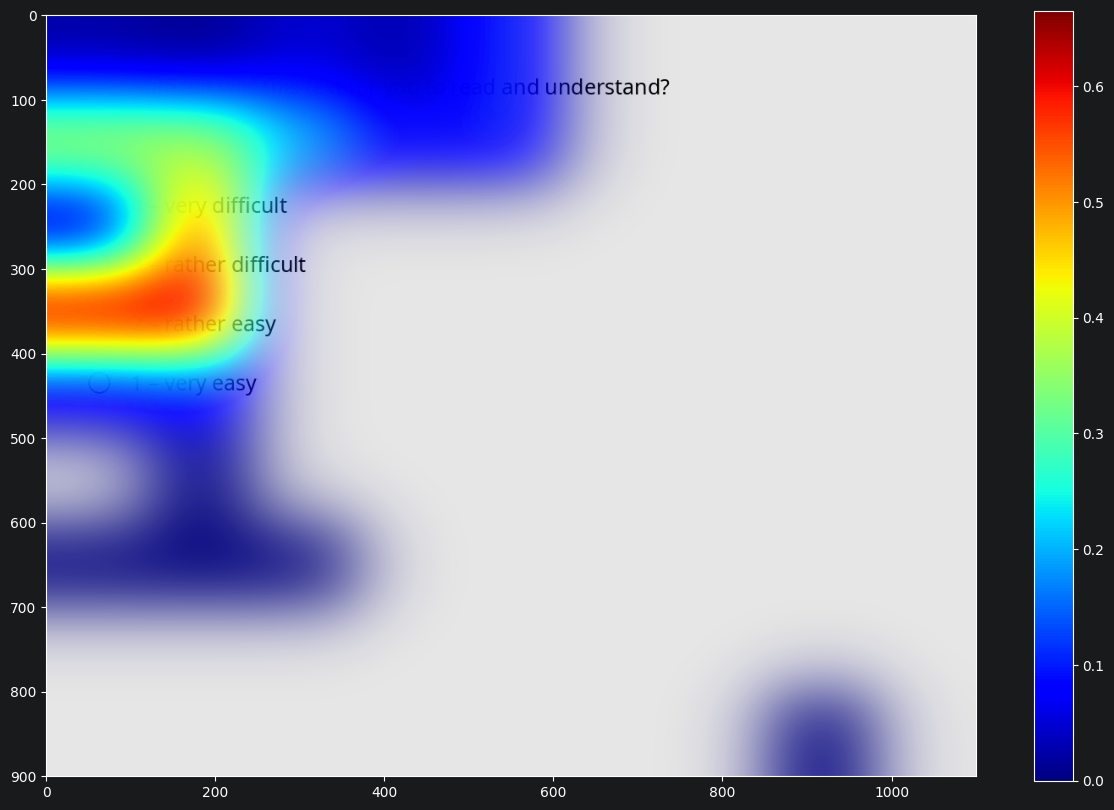

In [13]:
fig = pm.plotting.heatmap(
    pm_dataset.gaze[0],
    add_stimulus=True,
    path_to_image_stimulus="C:\\Users\saphi\PycharmProjects\\thesis\data\GGTG\stimuli\\blackout-zero.difficulty.png"
)

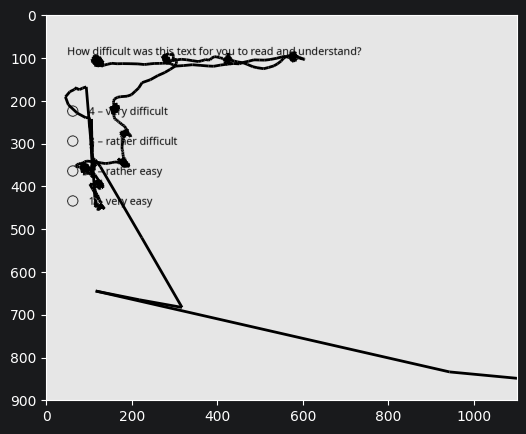

In [14]:
fig = pm.plotting.traceplot(
    pm_dataset.gaze[0],
    add_stimulus=True,
    path_to_image_stimulus="C:\\Users\saphi\PycharmProjects\\thesis\data\GGTG\stimuli\\blackout-zero.difficulty.png"
)

In [ ]:
df = gaze.samples

In [ ]:

df = df.with_columns([
    pl.col("pixel").list.get(0).mul(1500).alias("pos_x"),
    pl.col("pixel").list.get(1).mul(500).alias("pos_y"),
])
# Create a new pixel column with transformed values [1500*x, 500*y]
df = df.with_columns(
    pl.concat_list([
        #pl.col("pixel").list.get(0).fill_null(0).mul(1920),
        #pl.col("pixel").list.get(1).fill_null(0).mul(1080)
        pl.col("pixel").list.get(0).mul(1920),
        pl.col("pixel").list.get(1).mul(1080)
    ]).alias("pixel_scaled")
)
df

In [ ]:

# Assign back
gaze.samples = df
new_img = "C:\\Users\saphi\PycharmProjects\\thesis\stimulus_scaled.jpg"
pm.plotting.tsplot(
    gaze,
    channels=['pos_x', 'pos_y'],
    # Set separate y-axis for each channel.
    share_y=False,
    line_color="darkblue")
df = df.with_columns(
    pl.concat_list([
        pl.col("pixel").list.get(0).fill_null(0).mul(1920),
        pl.col("pixel").list.get(1).fill_null(0).mul(1080)
        #pl.col("pixel").list.get(0).mul(1920),
        #pl.col("pixel").list.get(1).mul(1080)
    ]).alias("pixel_scaled")
)

In [ ]:
gaze.samples = df
pm.plotting.heatmap(
    gaze,
    position_column='pixel_scaled',
    add_stimulus=True,
    path_to_image_stimulus="C:\\Users\saphi\PycharmProjects\\thesis\stimulus_scaled.jpg"
)

In [ ]:

fig = pm.plotting.traceplot(
    gaze,
    add_stimulus=True,
    position_column='pixel_scaled',
    #path_to_image_stimulus=f"data/mcfw_gaze/stimuli/{pm_dataset.fileinfo['ImageStimulus'].filter(pl.col('stimulus') == pm_dataset.gaze[0].metadata['stimulus'])['filepath'].item()}"
    path_to_image_stimulus=new_img,
)
pm_dataset.fileinfo['ImageStimulus'].filter(pl.col("stimulus") == pm_dataset.gaze[0].metadata["stimulus"])[
    "filepath"].item()
from PIL import Image


def scale_image_to_screen(image: Image.Image,
                          screen_size: tuple[int, int]) -> tuple[Image.Image, float, float, float, float]:
    """
    Scale a PIL Image to fit the screen while preserving aspect ratio.

    Returns:
        scaled_image          - the resized PIL Image
        offset_x, offset_y   - top-left position of image on screen (for letterboxing)
        scaled_w, scaled_h   - final image dimensions in pixels
    """
    img_w, img_h = image.size
    scr_w, scr_h = screen_size

    scale = min(scr_w / img_w, scr_h / img_h)

    scaled_w = int(img_w * scale)
    scaled_h = int(img_h * scale)

    scaled_image = image.resize((scaled_w, scaled_h), Image.LANCZOS)

    offset_x = (scr_w - scaled_w) / 2
    offset_y = (scr_h - scaled_h) / 2

    return scaled_image, offset_x, offset_y, scaled_w, scaled_h


def place_on_screen(scaled_image: Image.Image,
                    screen_size: tuple[int, int],
                    offset_x: float, offset_y: float,
                    background: tuple[int, int, int] = (0, 0, 0)) -> Image.Image:
    """
    Paste the scaled image onto a full-screen canvas with letterbox bars.

    Returns a new PIL Image at screen resolution.
    """
    canvas = Image.new("RGB", screen_size, background)
    canvas.paste(scaled_image, (int(offset_x), int(offset_y)))
    return canvas


dataset = "mcfw_gaze"
dataset_paths = pm.DatasetPaths(root='data/')
dataset = pm.Dataset(dataset, path=dataset_paths)
dataset.scan()
dataset = dataset.load(subset={'subject_id': "001", "stimulus": "22"})


def normalized_to_pixels(norm_x: float, norm_y: float,
                         offset_x: float, offset_y: float,
                         scaled_w: float, scaled_h: float) -> tuple[float, float]:
    """
    Map Tobii normalized gaze coordinates (0–1) to pixel coordinates
    within the scaled image.

    Returns (pixel_x, pixel_y) relative to the full screen.
    To get coordinates relative to the image itself, subtract the offsets.
    """
    pixel_x = norm_x * scaled_w + offset_x
    pixel_y = norm_y * scaled_h + offset_y

    return pixel_x, pixel_y


from PIL import Image

screen = (1920, 1080)
for image in range(20, 100):
    img = Image.open(f"C:\\Users\saphi\PycharmProjects\\thesis\data\mcfw_gaze\\raw\dataset\stimuli\\{image}.jpg")

    scaled_img, offset_x, offset_y, scaled_w, scaled_h = scale_image_to_screen(img, screen)

    # Get the full screen image with letterbox bars
    screen_img = place_on_screen(scaled_img, screen, offset_x, offset_y)
    screen_img.save(f"C:\\Users\saphi\PycharmProjects\\thesis\data\mcfw_gaze\\stimuli\\{image}.jpg")

# Gaze mapping still works the same way
px, py = normalized_to_pixels(0.5, 0.5, offset_x, offset_y, scaled_w, scaled_h)
screen_img